In [3]:
pip install pandas numpy nltk matplotlib seaborn wordcloud scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv("sentiment analysis.csv")

df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00.000000000,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00.000000000,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00.000000000,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00.000000000,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00.000000000,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal


In [5]:
df.shape

df.columns

df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Complaint ID      126974 non-null  int64 
 1   Category          126974 non-null  object
 2   Sub Category      126974 non-null  object
 3   Grievance Date    126974 non-null  object
 4   Ward Name         126974 non-null  object
 5   Grievance Status  126920 non-null  object
 6   Staff Remarks     126920 non-null  object
 7   Staff Name        126920 non-null  object
dtypes: int64(1), object(7)
memory usage: 7.8+ MB


Complaint ID         0
Category             0
Sub Category         0
Grievance Date       0
Ward Name            0
Grievance Status    54
Staff Remarks       54
Staff Name          54
dtype: int64

In [6]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.shape

(126920, 8)

In [7]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [8]:
df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [9]:
import nltk

nltk.download('punkt')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sarov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarov\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category', 'clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return " ".join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarov\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sarov\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


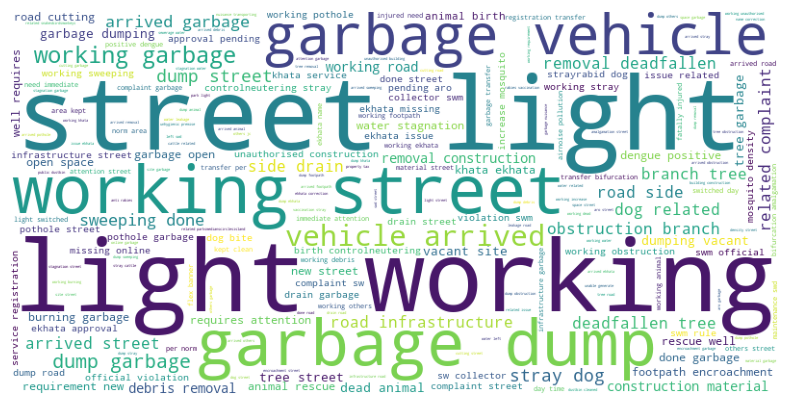

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [16]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

word_freq.most_common(10)

[('light', 41828),
 ('street', 41725),
 ('working', 40106),
 ('garbage', 32154),
 ('dump', 16129),
 ('vehicle', 12130),
 ('arrived', 12130),
 ('road', 7404),
 ('tree', 6040),
 ('dog', 5222)]

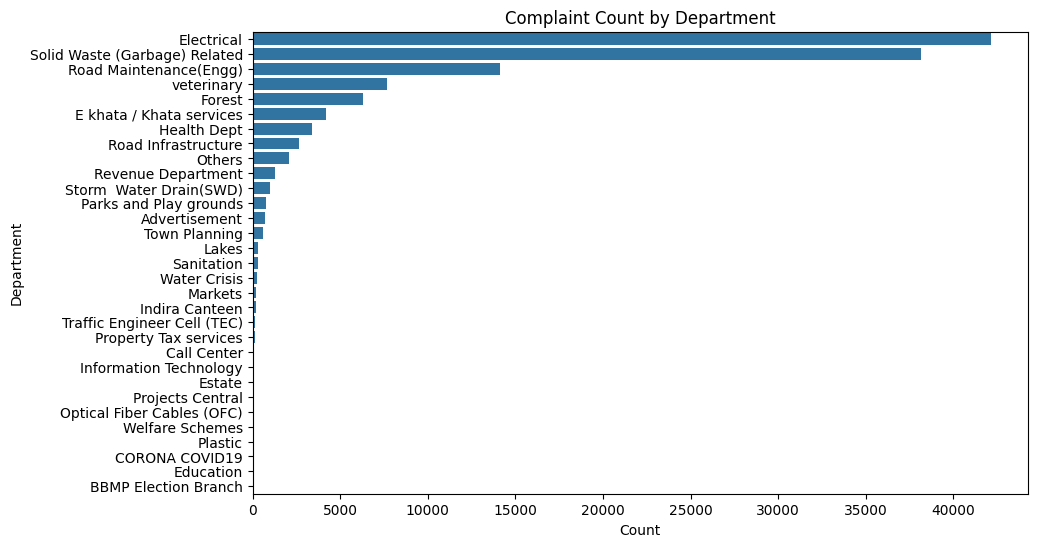

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)

plt.title("Complaint Count by Department")

plt.xlabel("Count")

plt.ylabel("Department")

plt.show()

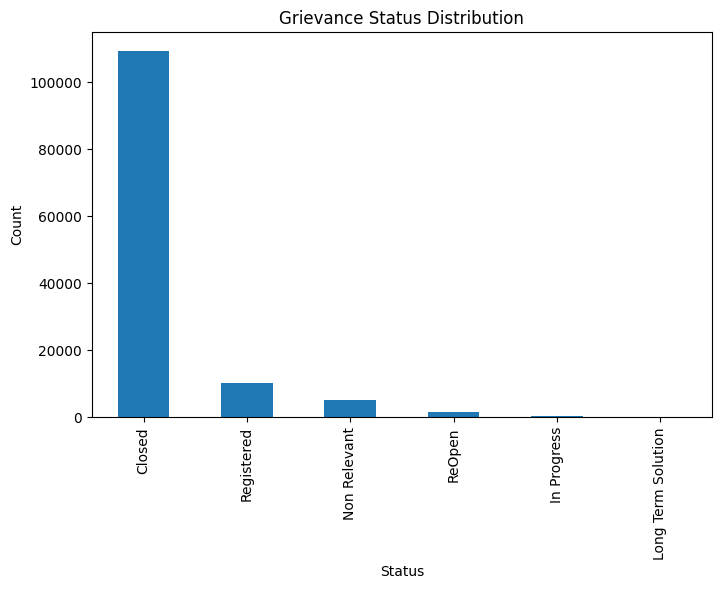

In [18]:
plt.figure(figsize=(8,5))

df['Grievance Status'].value_counts().plot(
    kind='bar'
)

plt.title("Grievance Status Distribution")

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()

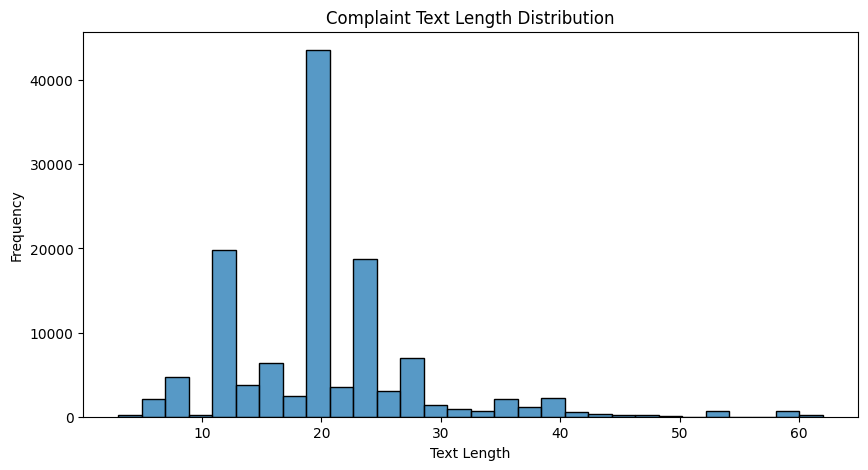

In [19]:
df['text_length'] = df['clean_text'].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(df['text_length'], bins=30)

plt.title("Complaint Text Length Distribution")

plt.xlabel("Text Length")

plt.ylabel("Frequency")

plt.show()

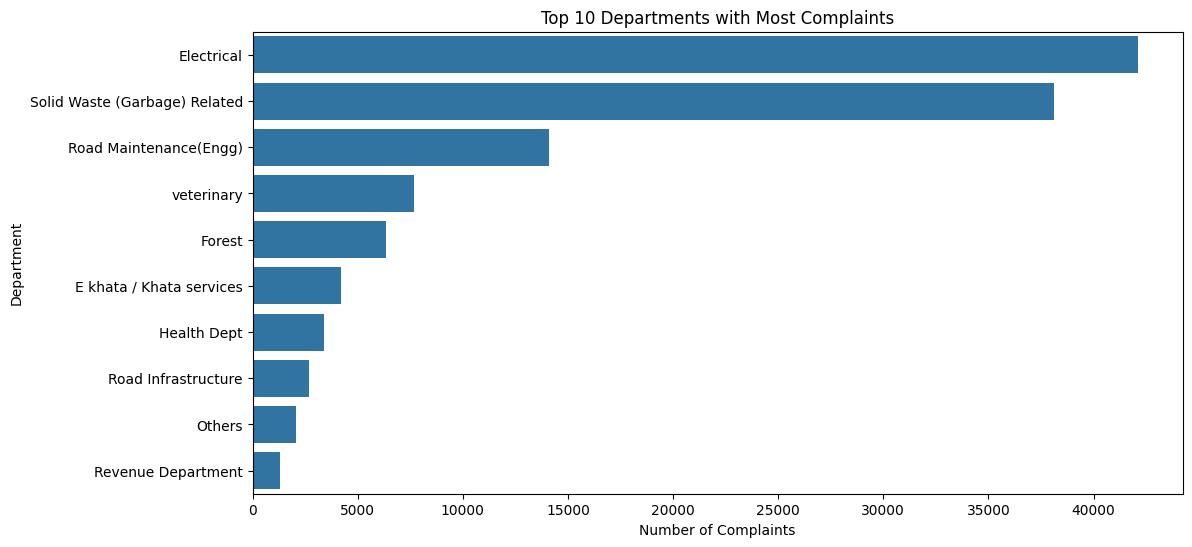

In [20]:
plt.figure(figsize=(12,6))

top_dept = df['Category'].value_counts().head(10)

sns.barplot(
    x=top_dept.values,
    y=top_dept.index
)

plt.title("Top 10 Departments with Most Complaints")

plt.xlabel("Number of Complaints")

plt.ylabel("Department")

plt.show()

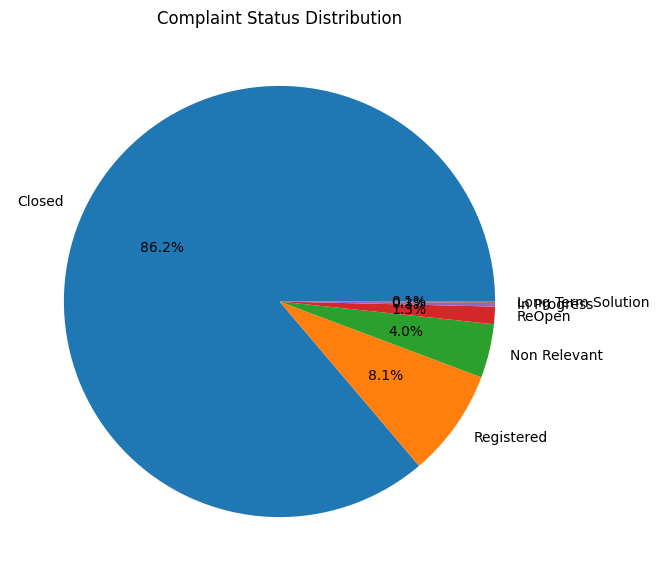

In [21]:
status_counts = df['Grievance Status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title("Complaint Status Distribution")

plt.show()

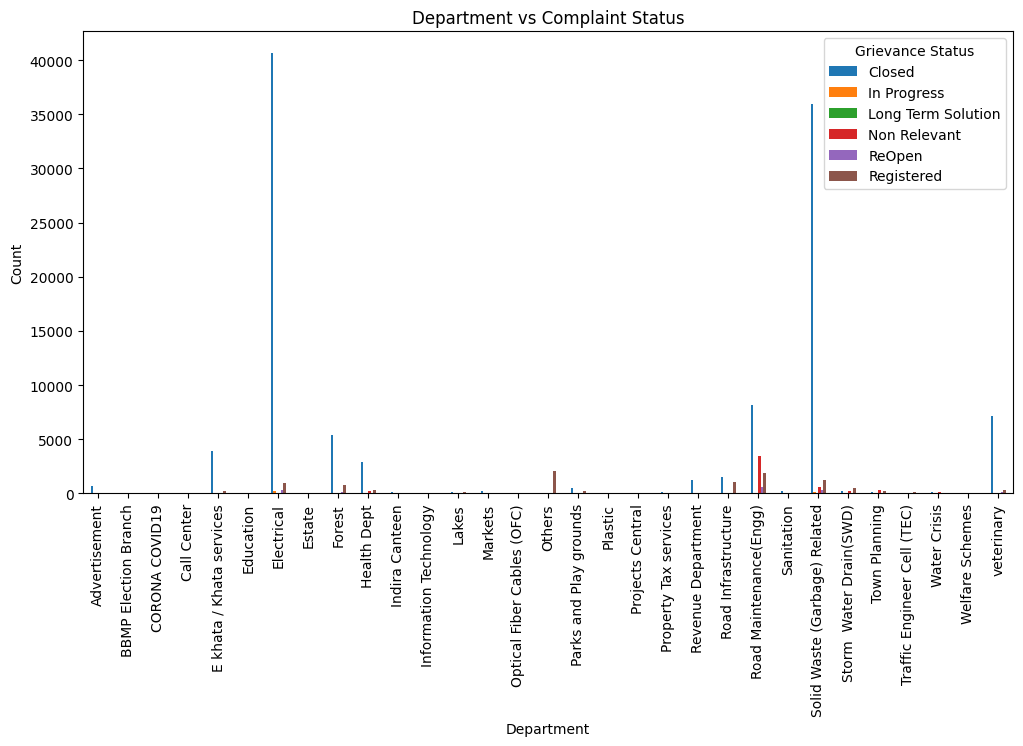

In [22]:
cross_tab = pd.crosstab(
    df['Category'],
    df['Grievance Status']
)

cross_tab.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Department vs Complaint Status")

plt.xlabel("Department")

plt.ylabel("Count")

plt.show()

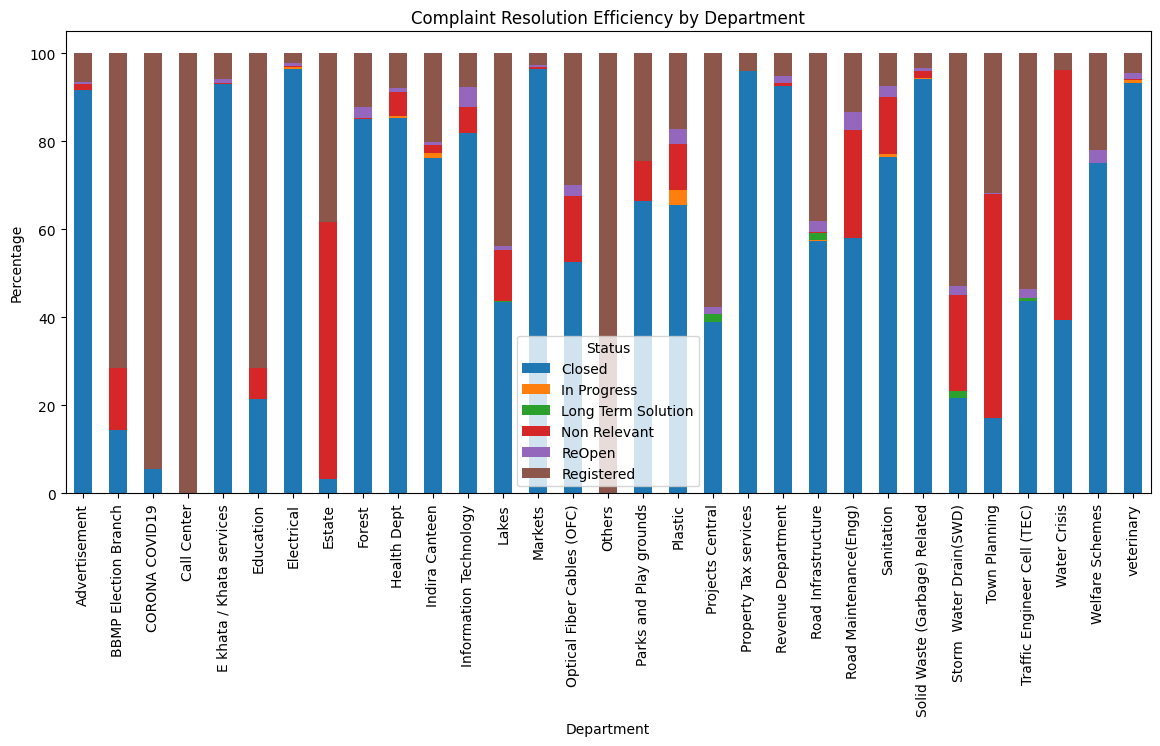

In [23]:
dept_status = pd.crosstab(
    df['Category'],
    df['Grievance Status']
)

dept_status_percent = dept_status.div(
    dept_status.sum(axis=1),
    axis=0
) * 100

dept_status_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title("Complaint Resolution Efficiency by Department")

plt.ylabel("Percentage")

plt.xlabel("Department")

plt.legend(title="Status")

plt.show()

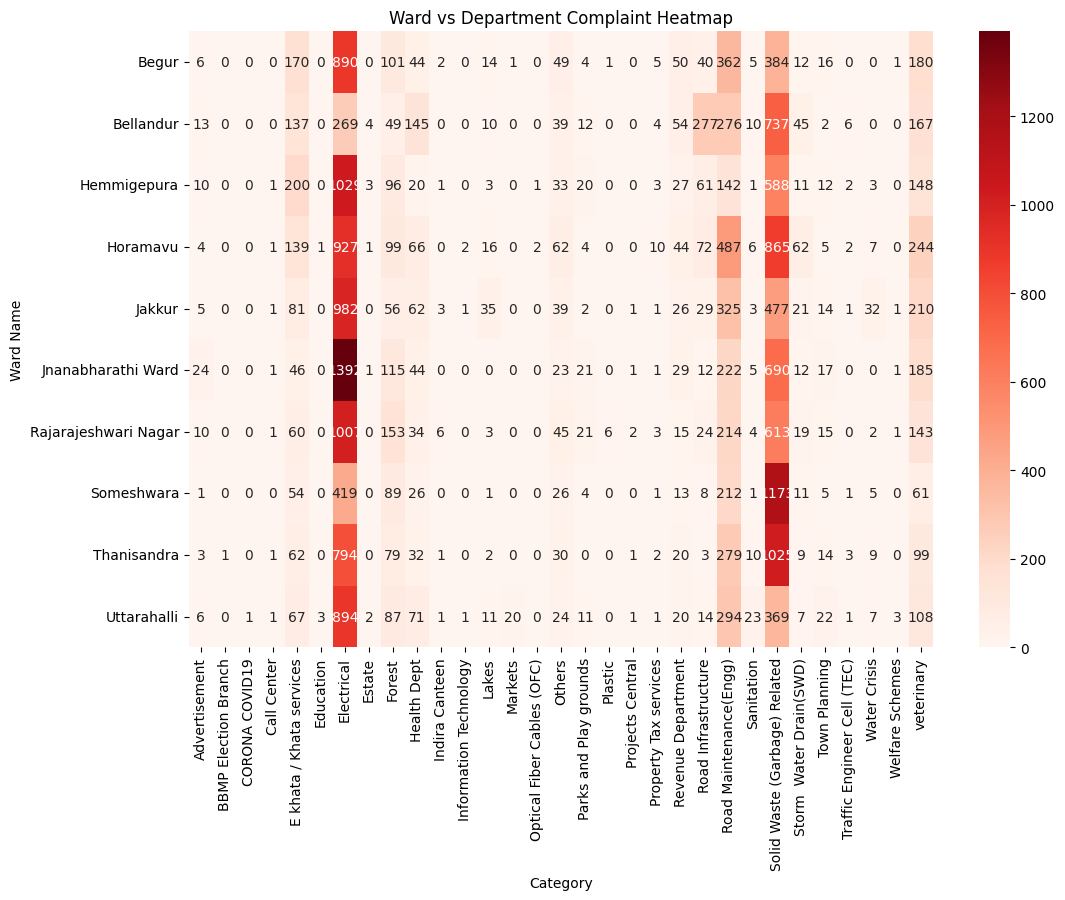

In [24]:
top_wards = df['Ward Name'].value_counts().head(10).index

filtered = df[df['Ward Name'].isin(top_wards)]

heatmap_data = pd.crosstab(
    filtered['Ward Name'],
    filtered['Category']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Ward vs Department Complaint Heatmap")

plt.show()

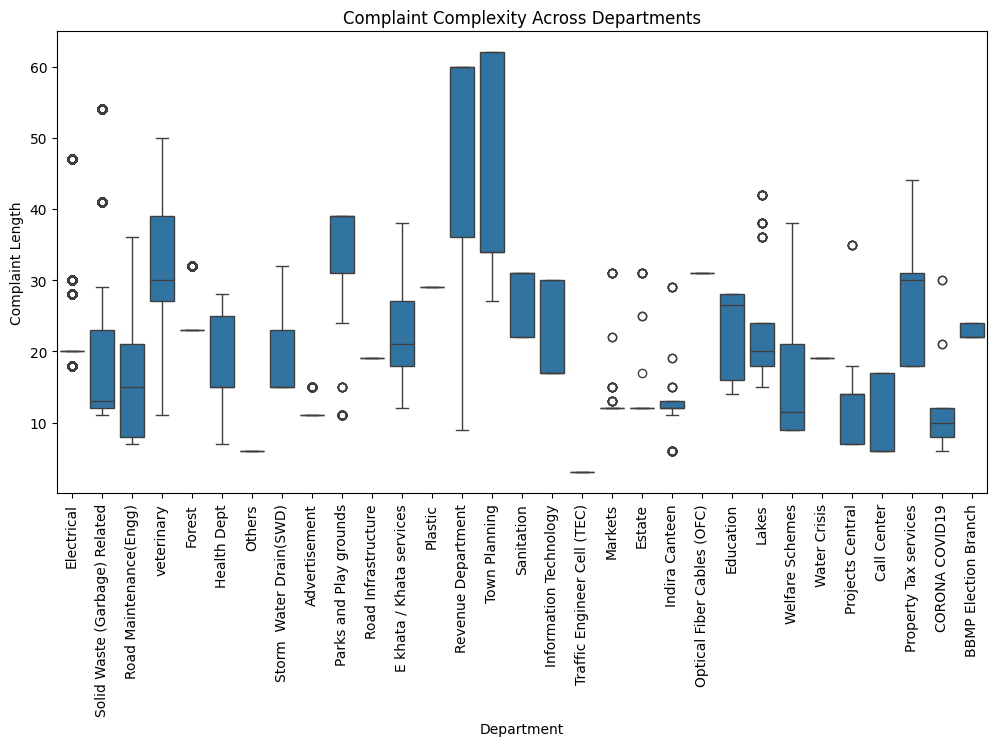

In [25]:
df['text_length'] = df['clean_text'].apply(len)

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Category',
    y='text_length',
    data=df
)

plt.xticks(rotation=90)

plt.title("Complaint Complexity Across Departments")

plt.xlabel("Department")

plt.ylabel("Complaint Length")

plt.show()

Topic Modeling & Department Prediction

STEP 1 — Features and Target

In [26]:
X = df['clean_text']

y = df['Category']

STEP 2 — TF-IDF Vectorization

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_vectorized = tfidf.fit_transform(X)

print(X_vectorized.shape)

(126920, 327)
